# SVC Kernel's indepth intution and practical Implementation

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [135]:
import plotly.express as px

In [136]:
r = 5
# It creates 100 data points each for negetive and positive values of r
x = np.linspace(-r , r , 100)
# equation of circle (x−h)2+(y−k)2=r2 
# but in this case 
# If the center is at (0,0):
# the center are at origin (x2+y2=r2)
y = np.sqrt((2*r)**2 - x**2)

# Creating Circle
y_full = np.hstack([x , x])
x_full = np.hstack([y , -y])
print(x.shape , y.shape)

(100,) (100,)


In [137]:
x1=np.linspace(-r , r , 100)
y1 = np.sqrt(r**2 - x1**2)

y1_full = np.hstack([x1 , x1])
x1_full = np.hstack([-y1 , y1])

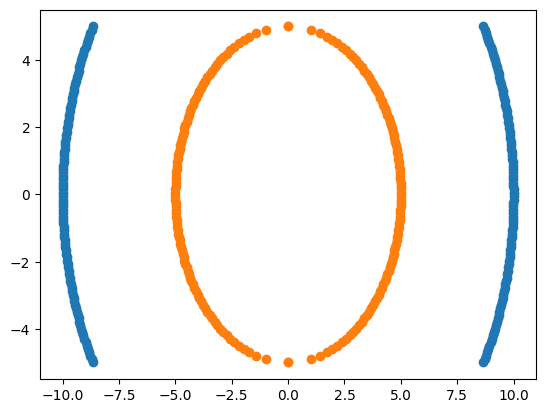

In [138]:
plt.scatter(x_full ,y_full)
plt.scatter(x1_full , y1_full)

In [139]:
np.vstack([y,x]).T

array([[ 8.66025404, -5.        ],
       [ 8.71779204, -4.8989899 ],
       [ 8.77378994, -4.7979798 ],
       [ 8.82827705, -4.6969697 ],
       [ 8.88128118, -4.5959596 ],
       [ 8.93282873, -4.49494949],
       [ 8.98294476, -4.39393939],
       [ 9.03165312, -4.29292929],
       [ 9.07897646, -4.19191919],
       [ 9.12493632, -4.09090909],
       [ 9.16955321, -3.98989899],
       [ 9.21284664, -3.88888889],
       [ 9.25483518, -3.78787879],
       [ 9.29553652, -3.68686869],
       [ 9.3349675 , -3.58585859],
       [ 9.37314414, -3.48484848],
       [ 9.41008171, -3.38383838],
       [ 9.44579475, -3.28282828],
       [ 9.4802971 , -3.18181818],
       [ 9.51360192, -3.08080808],
       [ 9.54572176, -2.97979798],
       [ 9.57666854, -2.87878788],
       [ 9.60645359, -2.77777778],
       [ 9.63508769, -2.67676768],
       [ 9.66258107, -2.57575758],
       [ 9.68894344, -2.47474747],
       [ 9.714184  , -2.37373737],
       [ 9.73831149, -2.27272727],
       [ 9.76133416,

### Observation
Convert 1-D to 2-D

In [140]:
df1 = pd.DataFrame(np.vstack([y,x]).T , columns=['X1' , 'X2'])
df1['Y'] = 0

In [141]:
df2 = pd.DataFrame(np.vstack([y1 , x1]).T , columns=['X1' , 'X2'])
df2['Y'] = 1

In [142]:
df = pd.concat([df1 , df2])
df.tail()

,X1,X2,Y
95,1.969049,4.59596,1
96,1.714198,4.69697,1
97,1.406908,4.79798,1
98,0.999949,4.89899,1
99,0.000000,5.00000,1


In [143]:
# divide feature in to Dependent and Independent Features
X = df.iloc[: , :2] # Independent
y = df.iloc[: , -1] # Dependent

## Polynomial Kernel 
# K(x,y) = (x**Ty + c)**d

In [144]:
# We need to find the component of the polynomial kernel
# X1, X2,X3_square , X2_square , X1*X2
df['X1_Square'] = df['X1']**2
df['X2_Square'] = df['X2']**2
df['X1*X2'] = df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [145]:
# Independent and Dependent Features
X = df[['X1' , 'X2' , 'X1_Square' , 'X2_Square' , 'X1*X2']]
y = df[['Y']]

In [146]:
y

,Y
0,0
1,0
2,0
3,0
4,0
...,...
95,1
96,1
97,1
98,1


In [147]:
X

,X1,X2,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,78.877155,21.122845,-40.818009
...,...,...,...,...,...
95,1.969049,4.59596,3.877155,21.122845,9.049671
96,1.714198,4.69697,2.938476,22.061524,8.051537
97,1.406908,4.79798,1.979390,23.020610,6.750316
98,0.999949,4.89899,0.999898,24.000102,4.898740


## Applying Train Test Split

In [148]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X , y ,test_size= 0.25 , random_state=42)

In [149]:
fig = px.scatter_3d(df , x='X1' , y = 'X2' , z='X1*X2' , color='Y')
fig.show()

## Applying Model

### Linear Kernel

In [150]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
linear = SVC(kernel='linear')
linear.fit(X_train , y_train)
y_pred = linear.predict(X_test) 
accuracy_score(y_test , y_pred)

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

### Polynomial Kernel

In [151]:
polynomial = SVC(kernel='poly')
polynomial.fit(X_train , y_train)
y_pred = polynomial.predict(X_test) 
accuracy_score(y_test , y_pred)

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

### Sigmoid Kernel

In [152]:
sigmoid = SVC(kernel='sigmoid')
sigmoid.fit(X_train , y_train)
y_pred = sigmoid.predict(X_test) 
accuracy_score(y_test , y_pred)

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.96

### RBF Kernel  || Radian Basis Function

In [153]:
rbf = SVC(kernel='rbf')
rbf.fit(X_train , y_train)
y_pred = rbf.predict(X_test) 
accuracy_score(y_test , y_pred)

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

In [154]:
from sklearn.svm import SVC
param_grid = {
    'C' : [0.1 , 1 , 10 , 100] ,
    'gamma' : [1 , 0.1 , 0.01 , 0.001] ,
    'kernel' : ['polynomial' , 'rbf' , 'linear']
}

In [155]:
svc = SVC(kernel='poly')

In [156]:
svc.fit(X_train , y_train)

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [157]:
y_pred = svc.predict(X_test)

In [158]:
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report

In [159]:
score = accuracy_score(y_test , y_pred)
score

1.0

In [160]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        23

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

